In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv(r'C:\Users\dell\Downloads\Hotel_bookings_final.csv')

# 1. Data Cleaning
# Check for missing values and duplicates
print("Missing Values:\n", df.isnull().sum())
df = df.drop_duplicates()

# Convert dates to datetime objects (Crucial for temporal analysis)
# Replace 'booking_date' with the actual column name from your CSV
df['booking_date'] = pd.to_datetime(df['booking_date'])

# Convert cancellation to binary if it's a string (e.g., 'Yes'/'No' to 1/0)
# df['is_canceled'] = df['is_canceled'].map({'Yes': 1, 'No': 0}) 

print("Data Cleaning Complete.")

Missing Values:
 customer_id              0
property_id              0
city                     0
star_rating              0
booking_date             0
check_in_date         5468
check_out_date        5468
room_type                0
num_rooms_booked         0
stay_type                0
booking_channel          0
booking_value            0
costprice                0
markup                   0
selling_price            0
payment_method           0
refund_status            0
refund_amount            0
channel_of_booking       0
booking_status           0
travel_date              0
cashback                 0
coupon_redeem            0
Coupon USed?             0
dtype: int64
Data Cleaning Complete.


Status of bookings with missing dates:
booking_status
Cancelled    5045
Failed        423
Name: count, dtype: int64


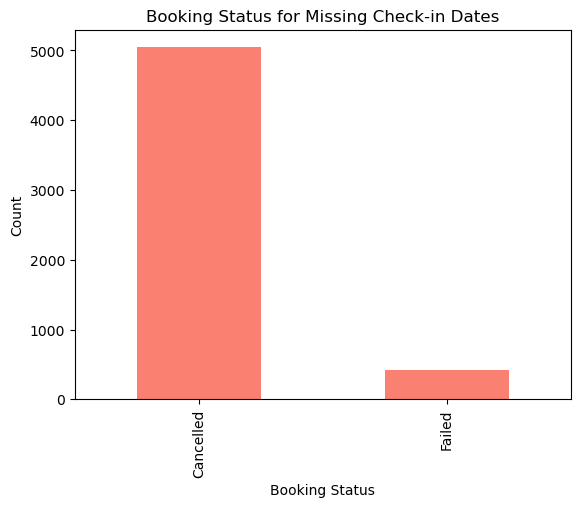

In [5]:
# 1. Check the distribution of 'booking_status' where 'check_in_date' is null
missing_dates_status = df[df['check_in_date'].isnull()]['booking_status'].value_counts()

print("Status of bookings with missing dates:")
print(missing_dates_status)

# 2. To see it visually (adds value to your analysis)
import matplotlib.pyplot as plt

missing_dates_status.plot(kind='bar', color='salmon')
plt.title('Booking Status for Missing Check-in Dates')
plt.ylabel('Count')
plt.xlabel('Booking Status')
plt.show()

Status of bookings with missing check-out dates:
booking_status
Cancelled    5045
Failed        423
Name: count, dtype: int64


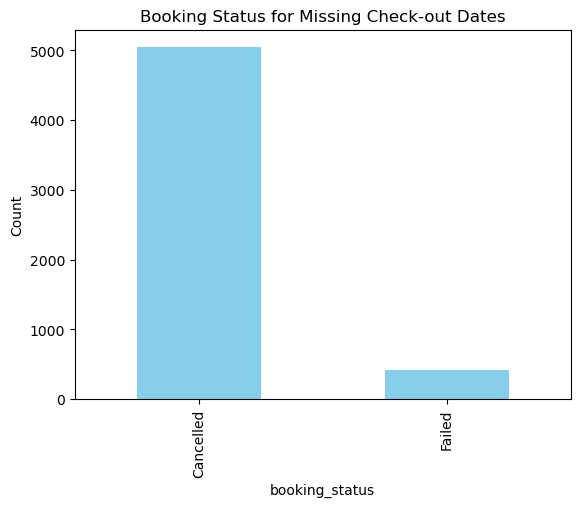

In [6]:
# Check the distribution of 'booking_status' where 'check_out_date' is null
missing_checkout_status = df[df['check_out_date'].isnull()]['booking_status'].value_counts()

print("Status of bookings with missing check-out dates:")
print(missing_checkout_status)

# Optional: Visualize this as well
missing_checkout_status.plot(kind='bar', color='skyblue')
plt.title('Booking Status for Missing Check-out Dates')
plt.ylabel('Count')
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_9940\4211198115.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('booking_date').resample('M').size().plot(marker='o', linestyle='-', color='b')


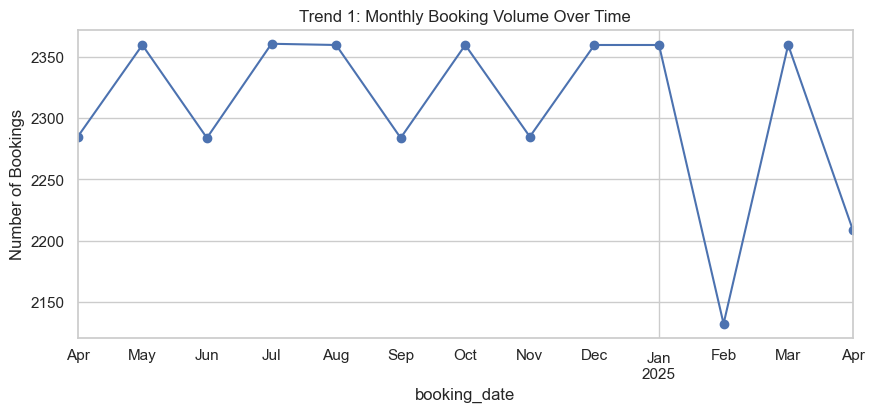

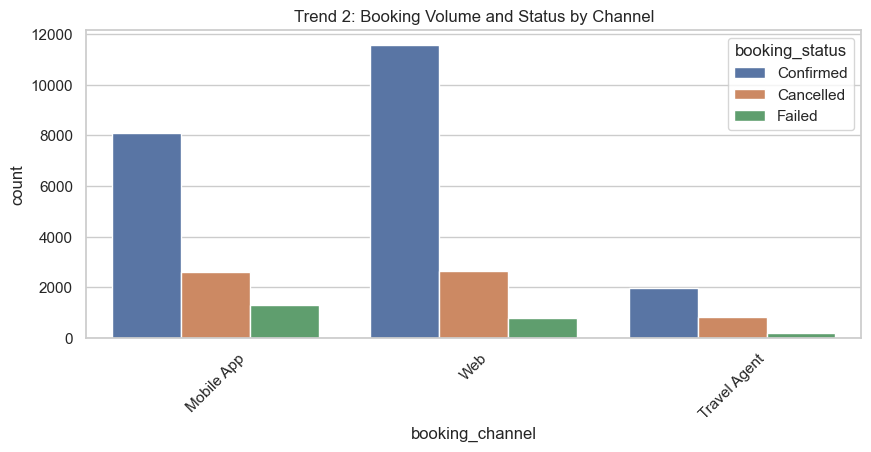

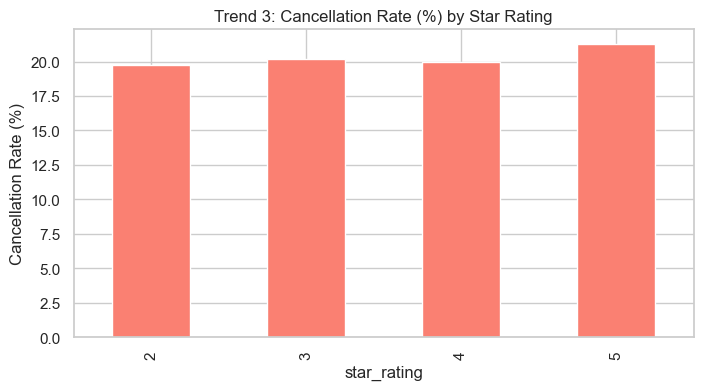

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional visual theme
sns.set_theme(style="whitegrid")

# --- Trend 1: Seasonal Booking Pattern ---
# Assuming 'booking_date' is already converted to datetime
plt.figure(figsize=(10, 4))
df.set_index('booking_date').resample('M').size().plot(marker='o', linestyle='-', color='b')
plt.title('Trend 1: Monthly Booking Volume Over Time')
plt.ylabel('Number of Bookings')
plt.show()

# --- Trend 2: Performance by Booking Channel ---
# We compare volume vs. cancellation status
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='booking_channel', hue='booking_status')
plt.title('Trend 2: Booking Volume and Status by Channel')
plt.xticks(rotation=45)
plt.show()

# --- Trend 3: Cancellation Behavior by Star Rating ---
# We calculate the cancellation rate per star rating
cancellation_by_star = df.groupby('star_rating')['booking_status'].apply(lambda x: (x == 'Cancelled').mean() * 100)
plt.figure(figsize=(8, 4))
cancellation_by_star.plot(kind='bar', color='salmon')
plt.title('Trend 3: Cancellation Rate (%) by Star Rating')
plt.ylabel('Cancellation Rate (%)')
plt.show()

In [9]:
print(df.columns.tolist())

['customer_id', 'property_id', 'city', 'star_rating', 'booking_date', 'check_in_date', 'check_out_date', 'room_type', 'num_rooms_booked', 'stay_type', 'booking_channel', 'booking_value', 'costprice', 'markup', 'selling_price', 'payment_method', 'refund_status', 'refund_amount', 'channel_of_booking', 'booking_status', 'travel_date', 'cashback', 'coupon_redeem', 'Coupon USed?']


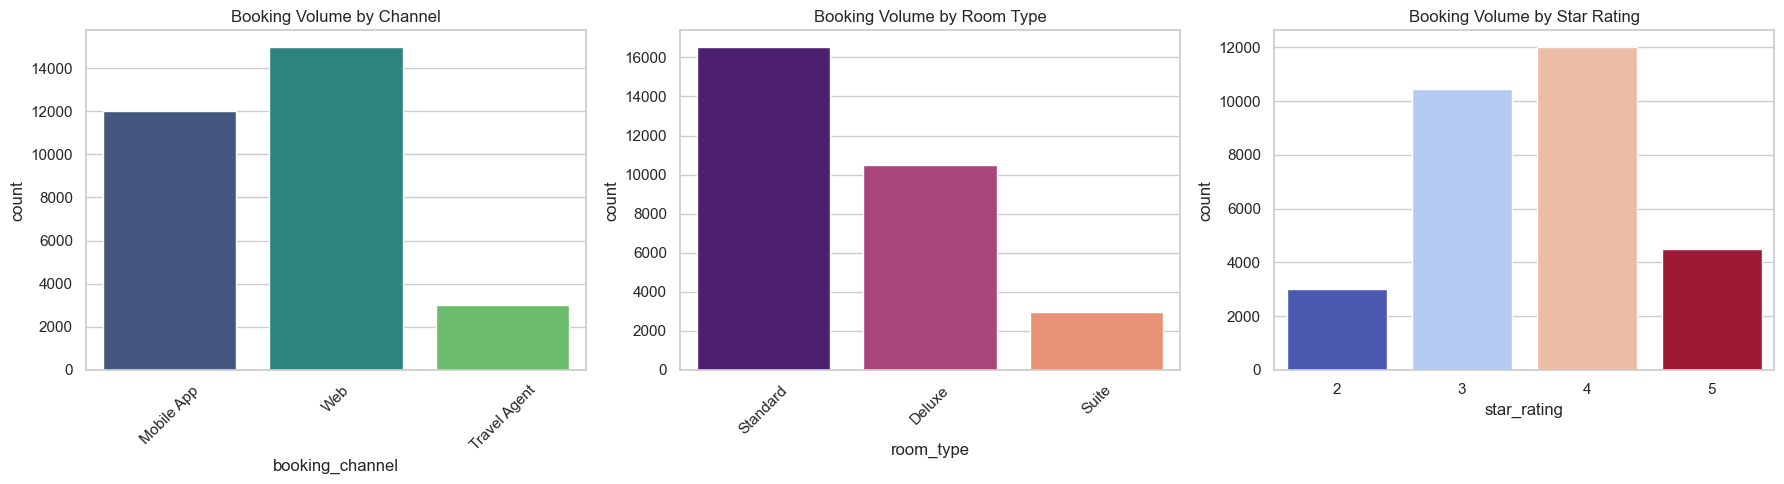

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Use hue=x and legend=False to satisfy the update
sns.countplot(data=df, x='booking_channel', hue='booking_channel', ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Booking Volume by Channel')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='room_type', hue='room_type', ax=axes[1], palette='magma', legend=False)
axes[1].set_title('Booking Volume by Room Type')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='star_rating', hue='star_rating', ax=axes[2], palette='coolwarm', legend=False)
axes[2].set_title('Booking Volume by Star Rating')

plt.tight_layout()
plt.show()

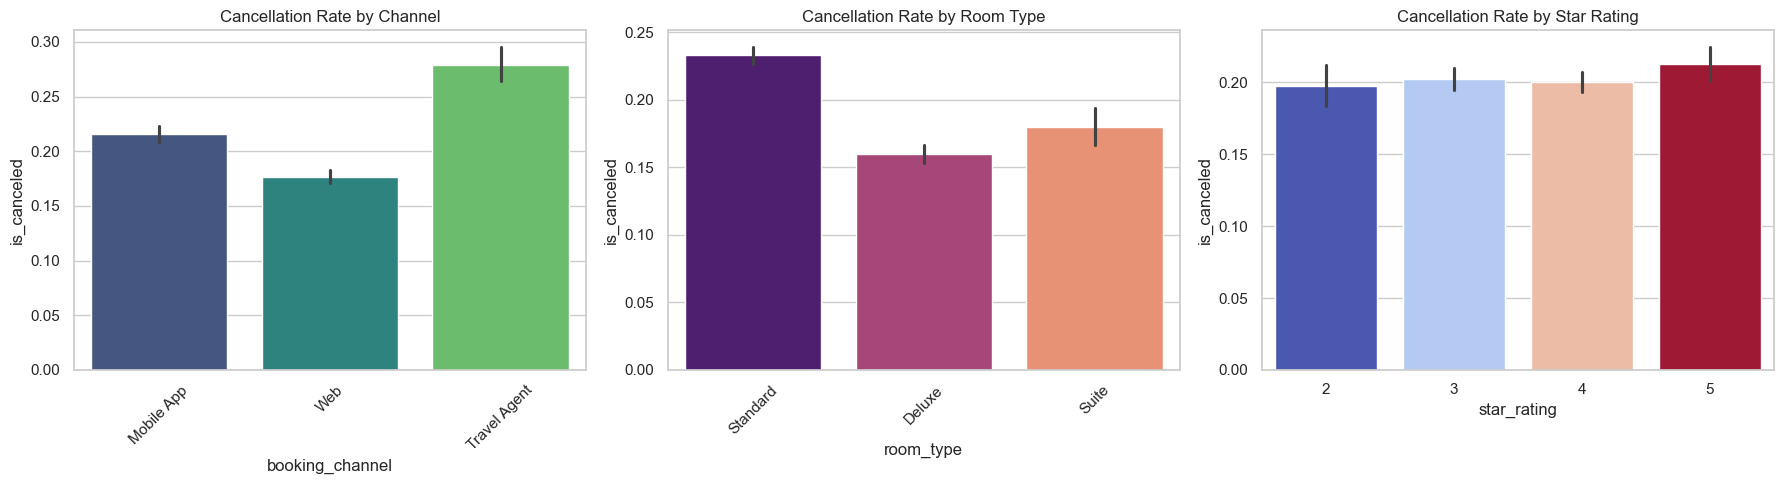

In [13]:
# Create the missing 'is_canceled' column
df['is_canceled'] = df['booking_status'].apply(lambda x: 1 if x == 'Cancelled' else 0)


import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Cancellation Rate by Channel
sns.barplot(data=df, x='booking_channel', y='is_canceled', hue='booking_channel', ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Cancellation Rate by Channel')
axes[0].tick_params(axis='x', rotation=45)

# 2. Cancellation Rate by Room Type
sns.barplot(data=df, x='room_type', y='is_canceled', hue='room_type', ax=axes[1], palette='magma', legend=False)
axes[1].set_title('Cancellation Rate by Room Type')
axes[1].tick_params(axis='x', rotation=45)

# 3. Cancellation Rate by Star Rating
sns.barplot(data=df, x='star_rating', y='is_canceled', hue='star_rating', ax=axes[2], palette='coolwarm', legend=False)
axes[2].set_title('Cancellation Rate by Star Rating')

plt.tight_layout()
plt.show()

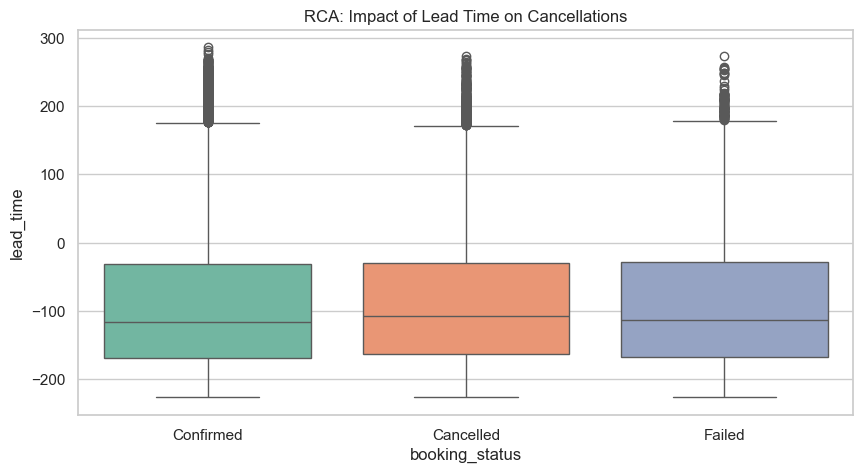

C:\Users\dell\AppData\Local\Temp\ipykernel_9940\401716116.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(perf_data.is_canceled[i], perf_data.net_profit[i], perf_data.index[i])


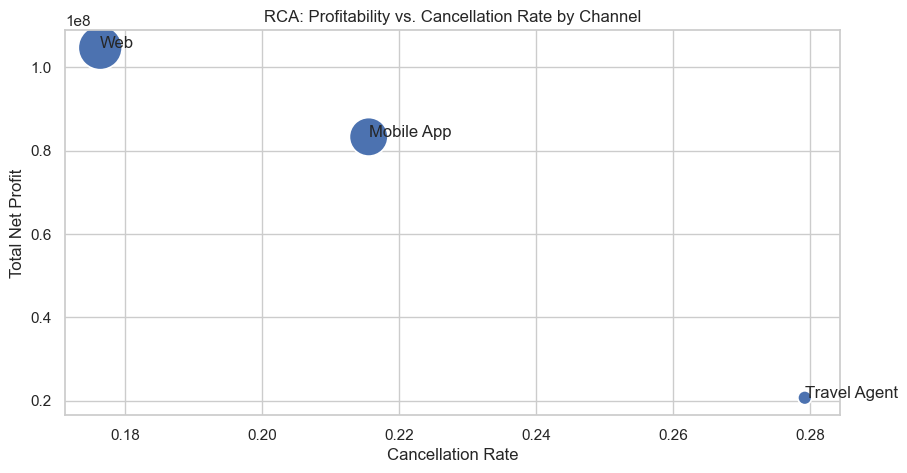

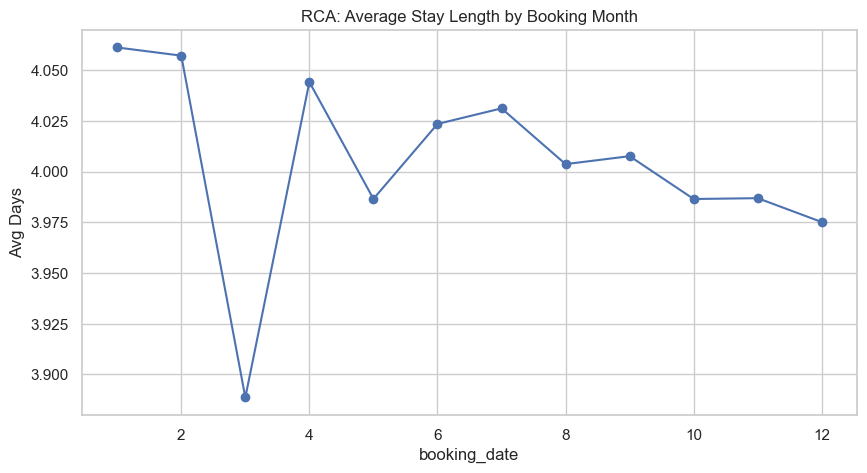

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Why are cancellations happening? (Analyzing Lead Time)
# Lead time = difference between booking date and travel date
df['lead_time'] = (pd.to_datetime(df['travel_date']) - pd.to_datetime(df['booking_date'])).dt.days

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='booking_status', y='lead_time', hue='booking_status', palette='Set2', legend=False)
plt.title('RCA: Impact of Lead Time on Cancellations')
plt.show()

# 2. Why do some channels/properties perform better? (Profitability Analysis)
# Calculating Net Profit
df['net_profit'] = df['selling_price'] - df['costprice'] - df['cashback'] - df['coupon_redeem']

# Compare Profitability vs Cancellation Rate by Channel
perf_data = df.groupby('booking_channel').agg({'net_profit': 'sum', 'is_canceled': 'mean'})

plt.figure(figsize=(10, 5))
sns.scatterplot(data=perf_data, x='is_canceled', y='net_profit', size='net_profit', sizes=(100, 1000), legend=False)
for i in range(perf_data.shape[0]):
    plt.text(perf_data.is_canceled[i], perf_data.net_profit[i], perf_data.index[i])
plt.title('RCA: Profitability vs. Cancellation Rate by Channel')
plt.xlabel('Cancellation Rate')
plt.ylabel('Total Net Profit')
plt.show()

# 3. Seasonal/Temporal Trends (Stay Length Analysis)
df['stay_length'] = (pd.to_datetime(df['check_out_date']) - pd.to_datetime(df['check_in_date'])).dt.days
# Removing potential outliers/errors for cleaner analysis
df_clean = df[df['stay_length'] > 0] 

plt.figure(figsize=(10, 5))
df_clean.groupby(df_clean['booking_date'].dt.month)['stay_length'].mean().plot(kind='line', marker='o')
plt.title('RCA: Average Stay Length by Booking Month')
plt.ylabel('Avg Days')
plt.show()